# Constraint Optimization and Torsional Energy Barriers

Finally perform the dihedral angle scan to get the potential energy surface as shown in figure S1 of the S1.

**Hint**: Run SCF calculations for different dihedral angle. You can omit optimization of the structure with dihedral [constraints](https://pyscf.org/user/geomopt.html).

In [1]:
# import directories 
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.drawOptions.addAtomIndices = True

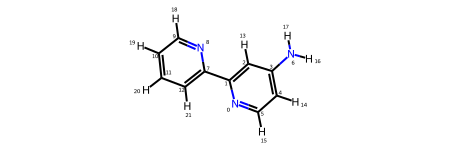

In [16]:
# 3D format from C10H9N3
smiles = "N1=C(C=C(C=C1)N)C1=NC=CC=C1"
mol = Chem.MolFromSmiles(smiles)
mol = Chem.AddHs(mol)
Chem.AllChem.EmbedMolecule(mol)
mol

## Constraint for N0C1N8C7 179.51 Degree

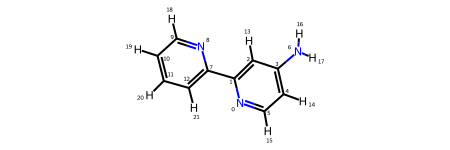

In [4]:
# Set the value to 0 for the conformer
Chem.AllChem.SetDihedralDeg(mol.GetConformer(0),0,1,7,8,179.51)

# Save the new conformer
Chem.MolToXYZFile(mol, "AMBPY_1.xyz")

# Looks like it is set to 179.51
mol

Now, we optimize the structure in gas phase (not solvent effect) and run frequency calculations to confirm convergence.

In [42]:
# SCF Energy (Reference)
from pyscf import gto, scf

mol = gto.M(atom="optimization_file/opt_AMBPY1.xyz")

# set basis set
mol.basis = "6-31+G**"

# set the functional
mf = mol.KS()
mf.xc = 'b3lyp'
mf.disp = 'd3bj'

# Run energy calculations
mf.kernel()

converged SCF energy = -543.869022578463


np.float64(-543.869022578463)

In [16]:
# Constraint at 179.81

with open("AMBPY1.txt", "w") as f:
    f.write("$set\n")
    f.write(f"dihedral 1 2 8 9 179.51\n")

print(open("AMBPY1.txt").read())

$set
dihedral 1 2 8 9 179.51



In [17]:
# Constraint
from pyscf.geomopt.geometric_solver import optimize

params = {"constraints": "AMBPY1.txt",}
mol_eq = optimize(mf, assert_convergence=True, **params)


geometric-optimize called with the following command line:
/home/wsluser/miniconda3/envs/simulation/lib/python3.12/site-packages/ipykernel_launcher.py -f /home/wsluser/.local/share/jupyter/runtime/kernel-d27d5e2e-2640-470c-9e25-7f7a5259ff5a.json

                                        ())))))))))))))))/                     
                                    ())))))))))))))))))))))))),                
                                *)))))))))))))))))))))))))))))))))             
                        #,    ()))))))))/                .)))))))))),          
                      #%%%%,  ())))))                        .))))))))*        
                      *%%%%%%,  ))              ..              ,))))))).      
                        *%%%%%%,         ***************/.        .)))))))     
                #%%/      (%%%%%%,    /*********************.       )))))))    
              .%%%%%%#      *%%%%%%,  *******/,     **********,      .))))))   
                .%%%%%%/      *%%


Geometry optimization cycle 1
Cartesian coordinates (Angstrom)
 Atom        New coordinates             dX        dY        dZ
   N   0.602940  -1.633295  -0.252701    0.000000  0.000000  0.000000
   C   0.297336  -0.339324  -0.063959    0.000000  0.000000  0.000000
   C   1.270431   0.609881   0.163792    0.000000  0.000000  0.000000
   C   2.597630   0.172475   0.191274    0.000000  0.000000  0.000000
   C   2.900013  -1.174155  -0.006315    0.000000  0.000000  0.000000
   C   1.882140  -2.081675  -0.230591    0.000000  0.000000  0.000000
   N   3.660219   1.085333   0.419760    0.000000  0.000000  0.000000
   C  -1.105752   0.070821  -0.101538    0.000000  0.000000  0.000000
   N  -1.464235   1.349208   0.090670    0.000000  0.000000  0.000000
   C  -2.747708   1.767171   0.063663    0.000000  0.000000  0.000000
   C  -3.759553   0.850725  -0.171882    0.000000  0.000000  0.000000
   C  -3.426504  -0.473202  -0.373886    0.000000  0.000000  0.000000
   C  -2.104092  -0.846543  -0.3

Step    0 : Gradient = 3.773e-02/9.262e-02 (rms/max) Energy = -543.8192739409
Hessian Eigenvalues: 2.30000e-02 2.30000e-02 2.30000e-02 ... 5.41260e-01 5.58471e-01 5.60697e-01



Geometry optimization cycle 2
Cartesian coordinates (Angstrom)
 Atom        New coordinates             dX        dY        dZ
   N   0.582997  -1.733046  -0.271342   -0.019943 -0.099751 -0.018641
   C   0.289529  -0.412953  -0.075369   -0.007807 -0.073629 -0.011410
   C   1.283321   0.558812   0.162826    0.012890 -0.051069 -0.000966
   C   2.655281   0.199647   0.207222    0.057651  0.027172  0.015948
   C   2.969155  -1.166715   0.003691    0.069142  0.007440  0.010006
   C   1.910293  -2.062441  -0.223961    0.028153  0.019234  0.006630
   N   3.682345   1.153120   0.444828    0.022126  0.067787  0.025068
   C  -1.149313  -0.007943  -0.118102   -0.043561 -0.078764 -0.016564
   N  -1.379290   1.324817   0.095610    0.084945 -0.024391  0.004940
   C  -2.673910   1.744805   0.066621    0.073798 -0.022366  0.002958
   C  -3.777611   0.898822  -0.167546   -0.018058  0.048097  0.004336
   C  -3.520608  -0.463494  -0.384351   -0.094104  0.009708 -0.010465
   C  -2.198796  -0.924431  -0.3

Step    1 : Displace = 9.894e-02/1.638e-01 (rms/max) Trust = 1.000e-01 (=) Grad_T = 1.469e-02/3.470e-02 (rms/max) E (change) = -543.8500855952 (-3.081e-02) Quality = 0.797
Hessian Eigenvalues: 2.29515e-02 2.30000e-02 2.30000e-02 ... 5.48356e-01 5.59370e-01 6.63834e-01


...

Step   24 : Displace = 3.250e-03/5.256e-03 (rms/max) Trust = 1.469e-02 (=) Grad_T = 1.568e-04/4.369e-04 (rms/max) E (change) = -543.8690197365 (-4.641e-06) Quality = 0.658
Constraint                         Current      Target       Diff.
Dihedral 1-2-8-9                 179.50866   179.51000    -0.00134
Hessian Eigenvalues: 1.25970e-02 2.14469e-02 2.29973e-02 ... 6.12743e-01 7.34078e-01 1.29890e+00



Geometry optimization cycle 26
Cartesian coordinates (Angstrom)
 Atom        New coordinates             dX        dY        dZ
   N   0.537803  -1.737992  -0.254104    0.001265 -0.001246 -0.000210
   C   0.306861  -0.366522  -0.086951   -0.000572 -0.001414 -0.000278
   C   1.310734   0.604127   0.100948   -0.001049 -0.000878 -0.000343
   C   2.670622   0.205548   0.132345   -0.000638  0.000528 -0.000315
   C   2.950775  -1.177486  -0.033231    0.000369  0.000668 -0.000036
   C   1.883142  -2.072098  -0.216723    0.001537 -0.000673 -0.000141
   N   3.725454   1.172856   0.226396   -0.001469  0.001529 -0.000020
   C  -1.146804   0.061811  -0.114354   -0.000963 -0.002426 -0.000325
   N  -1.389597   1.427680   0.062249    0.001016 -0.001966 -0.000086
   C  -2.732060   1.768261   0.027375    0.001687  0.000835  0.000411
   C  -3.796754   0.863038  -0.165105    0.001506  0.001148  0.000446
   C  -3.504393  -0.503674  -0.338476   -0.000172  0.000828  0.000228
   C  -2.160253  -0.908182  -0.

Step   25 : Displace = 2.199e-03/3.689e-03 (rms/max) Trust = 1.469e-02 (=) Grad_T = 1.722e-04/3.971e-04 (rms/max) E (change) = -543.8690201945 (-4.581e-07) Quality = 0.244
Hessian Eigenvalues: 1.27967e-02 2.08337e-02 2.29945e-02 ... 6.38235e-01 6.91422e-01 1.28499e+00



Geometry optimization cycle 27
Cartesian coordinates (Angstrom)
 Atom        New coordinates             dX        dY        dZ
   N   0.537221  -1.737769  -0.254136   -0.000582  0.000223 -0.000032
   C   0.307053  -0.366347  -0.086834    0.000192  0.000175  0.000117
   C   1.310859   0.604391   0.101125    0.000125  0.000264  0.000176
   C   2.670680   0.205442   0.132403    0.000058 -0.000105  0.000058
   C   2.951038  -1.177582  -0.033132    0.000263 -0.000096  0.000099
   C   1.882594  -2.071230  -0.216668   -0.000548  0.000868  0.000055
   N   3.725438   1.172533   0.227015   -0.000016 -0.000323  0.000619
   C  -1.146495   0.062110  -0.114203    0.000309  0.000299  0.000151
   N  -1.389577   1.427840   0.062464    0.000020  0.000160  0.000214
   C  -2.732254   1.767496   0.027441   -0.000194 -0.000765  0.000065
   C  -3.797315   0.862703  -0.165096   -0.000561 -0.000334  0.000009
   C  -3.504314  -0.503855  -0.338509    0.000080 -0.000181 -0.000033
   C  -2.159997  -0.907813  -0.

Step   26 : Displace = 7.164e-04/1.574e-03 (rms/max) Trust = 1.100e-03 (-) Grad_T = 7.314e-05/1.938e-04 (rms/max) E (change) = -543.8690210054 (-8.108e-07) Quality = 0.692
Hessian Eigenvalues: 1.27967e-02 2.08337e-02 2.29945e-02 ... 6.38235e-01 6.91422e-01 1.28499e+00
Converged! =D

    #==========================================================================#
    #| If this code has benefited your research, please support us by citing: |#
    #|                                                                        |#
    #| Wang, L.-P.; Song, C.C. (2016) "Geometry optimization made simple with |#
    #| translation and rotation coordinates", J. Chem, Phys. 144, 214108.     |#
    #| http://dx.doi.org/10.1063/1.4952956                                    |#
    #==========================================================================#
    Time elapsed since start of run_optimizer: 2575.147 seconds


In [18]:
# save the optimized geometry for visualization
mol_eq.tofile("const_AMBPY1.xyz")

'22\nXYZ from PySCF\nN           0.53722081       -1.73776932       -0.25413592\nC           0.30705313       -0.36634739       -0.08683402\nC           1.31085946        0.60439111        0.10112453\nC           2.67068000        0.20544246        0.13240285\nC           2.95103828       -1.17758191       -0.03313179\nC           1.88259363       -2.07123038       -0.21666783\nN           3.72543827        1.17253289        0.22701536\nC          -1.14649543        0.06210993       -0.11420325\nN          -1.38957742        1.42783999        0.06246350\nC          -2.73225357        1.76749638        0.02744065\nC          -3.79731547        0.86270342       -0.16509650\nC          -3.50431351       -0.50385529       -0.33850881\nC          -2.15999696       -0.90781253       -0.31241183\nH           1.01028741        1.65262184        0.22225068\nH           3.98612322       -1.53962762       -0.01598880\nH           2.09849549       -3.14546804       -0.34325940\nH           3.42297

In [19]:
# SCF energy for specific angle
from pyscf import gto, scf

mol = gto.M(atom="const_AMBPY1.xyz")

# set basis set
mol.basis = "6-31+G**"

# set the functional
mf = mol.KS()
mf.xc = 'b3lyp'
mf.disp = 'd3bj'

# Run energy calculations
neutral_energy = mf.kernel()

converged SCF energy = -543.869021005289


## Torsional energy barrier for N0C1N8C7 179.51 Degree

In [2]:
# Torsional energy barrier with reference
E_max = -543.86902100527 # SCF Energy theta (angle)
E_min = -543.869022713094 # SCF Energy reference from convergence

Delta_E = (E_max - E_min) * 2625.4996 #from Hartree to kJ/mol
Delta_E

0.0044838909991686705

## Constraint for N0C1N8C7 170.81 Degree

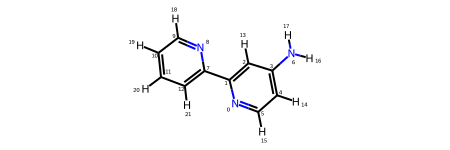

In [17]:
# Set the value to 0 for the conformer
Chem.AllChem.SetDihedralDeg(mol.GetConformer(0),0,1,7,8,170.81)

# Save the new conformer
Chem.MolToXYZFile(mol, "AMBPY_2.xyz")

# Looks like it is set to 179.51
mol

In [18]:
# SCF Energy
from pyscf import gto, scf

mol = gto.M(atom="AMBPY_2.xyz")

# set basis set
mol.basis = "6-31+G**"

# set the functional
mf = mol.KS()
mf.xc = 'b3lyp'
mf.disp = 'd3bj'

In [21]:
# Constraint at 170.81

with open("AMBPY2.txt", "w") as f:
    f.write("$set\n")
    f.write(f"dihedral 1 2 8 9 170.81\n")

print(open("AMBPY2.txt").read())

$set
dihedral 1 2 8 9 170.81



In [22]:
# Constraint
from pyscf.geomopt.geometric_solver import optimize

params = {"constraints": "AMBPY2.txt",}
mol_eq = optimize(mf, assert_convergence=True, **params)


geometric-optimize called with the following command line:
/home/wsluser/miniconda3/envs/simulation/lib/python3.12/site-packages/ipykernel_launcher.py -f /home/wsluser/.local/share/jupyter/runtime/kernel-74758f2e-3b40-45d9-95d3-5e1a197ed778.json

                                        ())))))))))))))))/                     
                                    ())))))))))))))))))))))))),                
                                *)))))))))))))))))))))))))))))))))             
                        #,    ()))))))))/                .)))))))))),          
                      #%%%%,  ())))))                        .))))))))*        
                      *%%%%%%,  ))              ..              ,))))))).      
                        *%%%%%%,         ***************/.        .)))))))     
                #%%/      (%%%%%%,    /*********************.       )))))))    
              .%%%%%%#      *%%%%%%,  *******/,     **********,      .))))))   
                .%%%%%%/      *%%


Geometry optimization cycle 1
Cartesian coordinates (Angstrom)
 Atom        New coordinates             dX        dY        dZ
   N   0.564251  -1.735907   0.021850    0.000000  0.000000 -0.000000
   C   0.248212  -0.448975   0.106135    0.000000  0.000000 -0.000000
   C   1.287786   0.466375   0.114392    0.000000  0.000000 -0.000000
   C   2.599523   0.060371   0.038248    0.000000  0.000000  0.000000
   C   2.861098  -1.289397  -0.047296    0.000000  0.000000  0.000000
   C   1.824434  -2.203434  -0.055599    0.000000  0.000000  0.000000
   N   3.646217   1.012066   0.048228    0.000000  0.000000  0.000000
   C  -1.114949   0.041313   0.189049    0.000000  0.000000  0.000000
   N  -1.340369   1.333967   0.456120    0.000000  0.000000  0.000000
   C  -2.561653   1.862178   0.549006    0.000000 -0.000000  0.000000
   C  -3.641213   1.034972   0.360492    0.000000  0.000000  0.000000
   C  -3.500195  -0.292365   0.084955    0.000000  0.000000 -0.000000
   C  -2.194228  -0.784958   0.0

Step    0 : Gradient = 4.588e-02/1.137e-01 (rms/max) Energy = -543.8179545049
Hessian Eigenvalues: 2.30000e-02 2.30000e-02 2.30000e-02 ... 5.63231e-01 5.78865e-01 5.92046e-01



Geometry optimization cycle 2
Cartesian coordinates (Angstrom)
 Atom        New coordinates             dX        dY        dZ
   N   0.465321  -1.820337   0.013276   -0.098930 -0.084430 -0.008574
   C   0.307220  -0.461244   0.093004    0.059008 -0.012269 -0.013131
   C   1.305450   0.561202   0.112937    0.017664  0.094827 -0.001455
   C   2.655737   0.101018   0.040535    0.056214  0.040647  0.002287
   C   2.945603  -1.299705  -0.046827    0.084505 -0.010308  0.000469
   C   1.792987  -2.122857  -0.052572   -0.031447  0.080577  0.003027
   N   3.707559   1.033163   0.055794    0.061342  0.021097  0.007566
   C  -1.129953   0.000832   0.173636   -0.015004 -0.040481 -0.015413
   N  -1.243216   1.349242   0.454631    0.097153  0.015275 -0.001489
   C  -2.543624   1.758009   0.527433    0.018029 -0.104169 -0.021573
   C  -3.790747   1.086120   0.376968   -0.149534  0.051148  0.016476
   C  -3.526090  -0.271874   0.097475   -0.025895  0.020491  0.012520
   C  -2.244030  -0.868086  -0.0

Step    1 : Displace = 9.962e-02/1.766e-01 (rms/max) Trust = 1.000e-01 (=) Grad_T = 3.143e-02/6.960e-02 (rms/max) E (change) = -543.8426561459 (-2.470e-02) Quality = 0.372
Constraint                         Current      Target       Diff.
Dihedral 1-2-8-9                 170.82797   170.81000     0.01797
Hessian Eigenvalues: 2.29817e-02 2.30000e-02 2.30000e-02 ... 5.78218e-01 5.82638e-01 6.49078e-01


...

Step   35 : Displace = 2.015e-03/3.227e-03 (rms/max) Trust = 1.028e-02 (=) Grad_T = 3.475e-04/8.653e-04 (rms/max) E (change) = -543.8688291394 (-2.984e-07) Quality = 0.043
Hessian Eigenvalues: 1.74634e-02 2.28889e-02 2.29980e-02 ... 6.72468e-01 1.04449e+00 1.85342e+00



Geometry optimization cycle 37
Cartesian coordinates (Angstrom)
 Atom        New coordinates             dX        dY        dZ
   N   0.452123  -1.757686  -0.003185    0.000712 -0.000087 -0.000194
   C   0.294491  -0.367133   0.055825   -0.000118  0.000085 -0.000111
   C   1.349065   0.567239   0.046338   -0.000107 -0.000012 -0.000022
   C   2.687565   0.107287  -0.031902   -0.000090  0.000322  0.000114
   C   2.894405  -1.296797  -0.098923   -0.000983  0.000160  0.000105
   C   1.779533  -2.151467  -0.081675    0.000440 -0.001634 -0.000142
   N   3.782514   1.027278  -0.139879    0.000001  0.000329 -0.000001
   C  -1.134986   0.125785   0.158978   -0.000271  0.000060 -0.000127
   N  -1.298036   1.490191   0.418427   -0.000954  0.000165 -0.000061
   C  -2.621751   1.888956   0.510890   -0.000678  0.001334  0.000092
   C  -3.740035   1.040638   0.370400   -0.000199  0.000860 -0.000093
   C  -3.526852  -0.328058   0.116131    0.000949  0.001071 -0.000119
   C  -2.205407  -0.790376   0.

Step   36 : Displace = 9.868e-04/2.056e-03 (rms/max) Trust = 1.008e-03 (-) Grad_T = 1.025e-04/2.756e-04 (rms/max) E (change) = -543.8688328608 (-3.721e-06) Quality = 0.801
Hessian Eigenvalues: 1.74684e-02 2.28814e-02 2.29975e-02 ... 6.65092e-01 1.04588e+00 1.80862e+00



Geometry optimization cycle 38
Cartesian coordinates (Angstrom)
 Atom        New coordinates             dX        dY        dZ
   N   0.451797  -1.757225  -0.003200   -0.000326  0.000461 -0.000015
   C   0.294181  -0.366755   0.055785   -0.000311  0.000379 -0.000040
   C   1.350010   0.566259   0.046132    0.000945 -0.000979 -0.000207
   C   2.688718   0.106982  -0.032076    0.001153 -0.000304 -0.000174
   C   2.895199  -1.297119  -0.099116    0.000794 -0.000322 -0.000193
   C   1.779339  -2.150541  -0.081713   -0.000194  0.000925 -0.000038
   N   3.783715   1.027319  -0.140664    0.001201  0.000041 -0.000785
   C  -1.135089   0.127045   0.159037   -0.000103  0.001260  0.000059
   N  -1.299117   1.491361   0.418409   -0.001081  0.001170 -0.000018
   C  -2.623095   1.889411   0.510637   -0.001345  0.000455 -0.000253
   C  -3.741404   1.041106   0.370099   -0.001369  0.000468 -0.000301
   C  -3.527282  -0.327448   0.115910   -0.000430  0.000610 -0.000221
   C  -2.205543  -0.789060   0.

Step   37 : Displace = 1.199e-03/1.772e-03 (rms/max) Trust = 1.425e-03 (+) Grad_T = 1.291e-04/3.917e-04 (rms/max) E (change) = -543.8688321999 (+6.610e-07) Quality = -0.682
Hessian Eigenvalues: 1.74684e-02 2.28814e-02 2.29975e-02 ... 6.65092e-01 1.04588e+00 1.80862e+00
Converged! =D

    #==========================================================================#
    #| If this code has benefited your research, please support us by citing: |#
    #|                                                                        |#
    #| Wang, L.-P.; Song, C.C. (2016) "Geometry optimization made simple with |#
    #| translation and rotation coordinates", J. Chem, Phys. 144, 214108.     |#
    #| http://dx.doi.org/10.1063/1.4952956                                    |#
    #==========================================================================#
    Time elapsed since start of run_optimizer: 2122.119 seconds


In [23]:
# save the optimized geometry for visualization
mol_eq.tofile("const_AMBPY2.xyz")

'22\nXYZ from PySCF\nN           0.45179716       -1.75722481       -0.00319955\nC           0.29418063       -0.36675458        0.05578485\nC           1.35001014        0.56625946        0.04613175\nC           2.68871760        0.10698230       -0.03207594\nC           2.89519937       -1.29711913       -0.09911629\nC           1.77933857       -2.15054115       -0.08171277\nN           3.78371515        1.02731857       -0.14066362\nC          -1.13508911        0.12704506        0.15903740\nN          -1.29911710        1.49136099        0.41840905\nC          -2.62309527        1.88941137        0.51063654\nC          -3.74140423        1.04110583        0.37009910\nC          -3.52728176       -0.32744847        0.11591024\nC          -2.20554287       -0.78905987        0.01026416\nH           1.10702706        1.63427808        0.10931377\nH           3.91100807       -1.70604651       -0.15995662\nH           1.93841895       -3.24103896       -0.12790693\nH           4.67256

In [3]:
# SCF Energy
from pyscf import gto, scf

mol = gto.M(atom="constraint_dihedral/const_AMBPY2.xyz")

# set basis set
mol.basis = "6-31+G**"

# set the functional
mf = mol.KS()
mf.xc = 'b3lyp'
mf.disp = 'd3bj'

# Run energy calculations
neutral_energy = mf.kernel()

converged SCF energy = -543.868832199782


## Torsional energy barrier for N0C1N8C7 170.81 Degree

In [4]:
# Torsional energy barrier with reference
E_max = -543.868832199782 # theta (angle)
E_min = -543.869022713094 # reference from convergence

Delta_E = (E_max - E_min) * 2625.4996 #from Hartree to kJ/mol
Delta_E

0.5001926243548809

## Constraint for N0C1N8C7 220.79 Degree

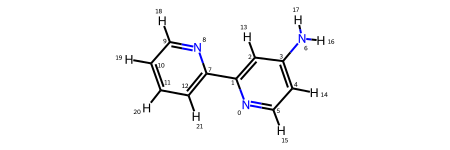

In [48]:
# 3D format from C10H9N3
smiles = "N1=C(C=C(C=C1)N)C1=NC=CC=C1"
mol = Chem.MolFromSmiles(smiles)
mol = Chem.AddHs(mol)
Chem.AllChem.EmbedMolecule(mol)
mol

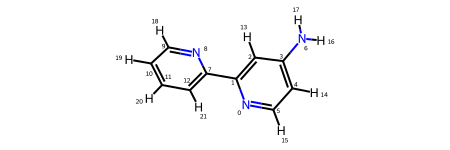

In [49]:
# Set the value to 0 for the conformer
Chem.AllChem.SetDihedralDeg(mol.GetConformer(0),0,1,7,8,220.79)

# Save the new conformer
Chem.MolToXYZFile(mol, "AMBPY_3.xyz")

# Looks like it is set to 220.79
mol

In [50]:
# SCF Energy
from pyscf import gto, scf

mol = gto.M(atom="AMBPY_1.xyz")

# set basis set
mol.basis = "6-31+G**"

# set the functional
mf = mol.KS()
mf.xc = 'b3lyp'
mf.disp = 'd3bj'

In [51]:
# Constraint at 220.79

with open("AMBPY3.txt", "w") as f:
    f.write("$set\n")
    f.write(f"dihedral 1 2 8 9 220.79\n")

print(open("AMBPY3.txt").read())

$set
dihedral 1 2 8 9 220.79



In [52]:
# Constraint
from pyscf.geomopt.geometric_solver import optimize

params = {"constraints": "AMBPY3.txt",}
mol_eq = optimize(mf, assert_convergence=True, **params)


geometric-optimize called with the following command line:
/home/wsluser/miniconda3/envs/simulation/lib/python3.12/site-packages/ipykernel_launcher.py -f /home/wsluser/.local/share/jupyter/runtime/kernel-74758f2e-3b40-45d9-95d3-5e1a197ed778.json

                                        ())))))))))))))))/                     
                                    ())))))))))))))))))))))))),                
                                *)))))))))))))))))))))))))))))))))             
                        #,    ()))))))))/                .)))))))))),          
                      #%%%%,  ())))))                        .))))))))*        
                      *%%%%%%,  ))              ..              ,))))))).      
                        *%%%%%%,         ***************/.        .)))))))     
                #%%/      (%%%%%%,    /*********************.       )))))))    
              .%%%%%%#      *%%%%%%,  *******/,     **********,      .))))))   
                .%%%%%%/      *%%


Geometry optimization cycle 1
Cartesian coordinates (Angstrom)
 Atom        New coordinates             dX        dY        dZ
   N   0.602940  -1.633295  -0.252701    0.000000  0.000000  0.000000
   C   0.297336  -0.339324  -0.063959    0.000000  0.000000  0.000000
   C   1.270431   0.609881   0.163792    0.000000  0.000000  0.000000
   C   2.597630   0.172475   0.191274    0.000000  0.000000  0.000000
   C   2.900013  -1.174155  -0.006315    0.000000  0.000000  0.000000
   C   1.882140  -2.081675  -0.230591    0.000000  0.000000  0.000000
   N   3.660219   1.085333   0.419760    0.000000  0.000000  0.000000
   C  -1.105752   0.070821  -0.101538    0.000000  0.000000  0.000000
   N  -1.464235   1.349208   0.090670    0.000000  0.000000  0.000000
   C  -2.747708   1.767171   0.063663    0.000000  0.000000  0.000000
   C  -3.759553   0.850725  -0.171882    0.000000  0.000000  0.000000
   C  -3.426504  -0.473202  -0.373886    0.000000  0.000000  0.000000
   C  -2.104092  -0.846543  -0.3

Step    0 : Gradient = 3.773e-02/9.262e-02 (rms/max) Energy = -543.8192739411
Hessian Eigenvalues: 2.30000e-02 2.30000e-02 2.30000e-02 ... 5.41260e-01 5.58471e-01 5.60697e-01



Geometry optimization cycle 2
Cartesian coordinates (Angstrom)
 Atom        New coordinates             dX        dY        dZ
   N   0.603542  -1.617951  -0.306045    0.000602  0.015344 -0.053344
   C   0.288849  -0.357886   0.035390   -0.008487 -0.018562  0.099349
   C   1.261418   0.586880   0.282617   -0.009013 -0.023001  0.118825
   C   2.593267   0.167499   0.224465   -0.004363 -0.004976  0.033191
   C   2.902695  -1.153411  -0.095657    0.002682  0.020744 -0.089342
   C   1.887069  -2.049735  -0.368169    0.004929  0.031940 -0.137578
   N   3.653871   1.074637   0.482913   -0.006348 -0.010696  0.063153
   C  -1.113479   0.054677   0.003298   -0.007727 -0.016144  0.104836
   N  -1.452534   1.352411   0.009073    0.011701  0.003203 -0.081597
   C  -2.728278   1.781875  -0.093477    0.019430  0.014704 -0.157140
   C  -3.749547   0.857569  -0.239999    0.010006  0.006844 -0.068117
   C  -3.432514  -0.484586  -0.287885   -0.006010 -0.011384  0.086001
   C  -2.117341  -0.868401  -0.1

Step    1 : Displace = 1.501e-01/2.954e-01 (rms/max) Trust = 1.000e-01 (=) Grad_T = 3.787e-02/9.271e-02 (rms/max) E (change) = -543.8174602794 (+1.814e-03) Quality = 0.621
Constraint                         Current      Target       Diff.
Dihedral 1-2-8-9                -163.42147   220.79000   -24.21147
Hessian Eigenvalues: 9.45852e-03 2.30000e-02 2.30000e-02 ... 5.41352e-01 5.58466e-01 5.60753e-01


...

Step   25 : Displace = 3.728e-03/7.412e-03 (rms/max) Trust = 1.767e-02 (=) Grad_T = 6.831e-05/1.623e-04 (rms/max) E (change) = -543.8646646856 (-1.270e-07) Quality = 0.360
Constraint                         Current      Target       Diff.
Dihedral 1-2-8-9                -139.22038   220.79000    -0.01038
Hessian Eigenvalues: 6.17708e-03 1.26226e-02 1.52322e-02 ... 6.91306e-01 8.41560e-01 1.19276e+00



Geometry optimization cycle 27
Cartesian coordinates (Angstrom)
 Atom        New coordinates             dX        dY        dZ
   N   0.574346  -1.609763  -0.653326    0.000226  0.000386 -0.001075
   C   0.308166  -0.358622  -0.084861    0.000212  0.000483 -0.001388
   C   1.280940   0.529909   0.414166    0.000280  0.000145 -0.000728
   C   2.647925   0.153204   0.385571    0.000300  0.000038 -0.000108
   C   2.964565  -1.118823  -0.162185    0.000313 -0.000006 -0.000140
   C   1.926242  -1.928006  -0.650956    0.000240  0.000271 -0.000549
   N   3.658588   0.983367   0.974935    0.000017 -0.000117  0.000308
   C  -1.149090   0.068371  -0.113186    0.000122  0.000778 -0.001397
   N  -1.382086   1.412056  -0.419262   -0.001260  0.000477 -0.001674
   C  -2.727444   1.745611  -0.482619   -0.001497 -0.000033 -0.000967
   C  -3.799057   0.851182  -0.283545   -0.000793 -0.000611  0.000391
   C  -3.514162  -0.498511  -0.000759    0.000280 -0.000284  0.001080
   C  -2.169047  -0.895806   0.

Step   26 : Displace = 1.372e-03/2.319e-03 (rms/max) Trust = 1.767e-02 (=) Grad_T = 4.669e-05/1.134e-04 (rms/max) E (change) = -543.8646637426 (+9.430e-07) Quality = 1.752
Constraint                         Current      Target       Diff.
Dihedral 1-2-8-9                -139.21314   220.79000    -0.00314
Hessian Eigenvalues: 6.35116e-03 1.25904e-02 1.56249e-02 ... 7.08719e-01 8.19589e-01 1.16553e+00



Geometry optimization cycle 28
Cartesian coordinates (Angstrom)
 Atom        New coordinates             dX        dY        dZ
   N   0.574473  -1.609734  -0.653055    0.000128  0.000029  0.000271
   C   0.308079  -0.358675  -0.084568   -0.000087 -0.000054  0.000292
   C   1.280649   0.530124   0.414342   -0.000291  0.000216  0.000176
   C   2.647610   0.153550   0.385562   -0.000315  0.000346 -0.000009
   C   2.964558  -1.118388  -0.162136   -0.000008  0.000435  0.000048
   C   1.926407  -1.927821  -0.650807    0.000165  0.000186  0.000149
   N   3.658292   0.983978   0.974740   -0.000296  0.000611 -0.000195
   C  -1.149235   0.067948  -0.112734   -0.000145 -0.000422  0.000452
   N  -1.381905   1.411643  -0.418846    0.000181 -0.000413  0.000416
   C  -2.727222   1.745227  -0.482467    0.000222 -0.000384  0.000153
   C  -3.798950   0.850892  -0.283726    0.000107 -0.000291 -0.000180
   C  -3.514251  -0.498853  -0.001002   -0.000089 -0.000342 -0.000243
   C  -2.169211  -0.896259   0.

Step   27 : Displace = 4.511e-04/9.421e-04 (rms/max) Trust = 2.500e-02 (+) Grad_T = 1.228e-05/3.265e-05 (rms/max) E (change) = -543.8646636347 (+1.079e-07) Quality = 0.798
Constraint                         Current      Target       Diff.
Dihedral 1-2-8-9                -139.21275   220.79000    -0.00275
Hessian Eigenvalues: 6.35116e-03 1.25904e-02 1.56249e-02 ... 7.08719e-01 8.19589e-01 1.16553e+00
Converged! =D

    #==========================================================================#
    #| If this code has benefited your research, please support us by citing: |#
    #|                                                                        |#
    #| Wang, L.-P.; Song, C.C. (2016) "Geometry optimization made simple with |#
    #| translation and rotation coordinates", J. Chem, Phys. 144, 214108.     |#
    #| http://dx.doi.org/10.1063/1.4952956                                    |#
    #==========================================================================#
    Time elapse

In [53]:
# save the constraint for visualization
mol_eq.tofile("const_AMBPY3.xyz")

'22\nXYZ from PySCF\nN           0.57447325       -1.60973437       -0.65305485\nC           0.30807901       -0.35867530       -0.08456817\nC           1.28064851        0.53012427        0.41434191\nC           2.64760991        0.15354969        0.38556158\nC           2.96455787       -1.11838827       -0.16213627\nC           1.92640729       -1.92782085       -0.65080698\nN           3.65829190        0.98397750        0.97474005\nC          -1.14923478        0.06794846       -0.11273367\nN          -1.38190488        1.41164291       -0.41884633\nC          -2.72722248        1.74522739       -0.48246654\nC          -3.79895003        0.85089174       -0.28372573\nC          -3.51425133       -0.49885286       -0.00100210\nC          -2.16921061       -0.89625858        0.07854640\nH           0.97038233        1.50671086        0.80559688\nH           4.00683153       -1.45632114       -0.21025844\nH           2.17266155       -2.90838760       -1.09171271\nH           3.39903

In [7]:
# SCF Energy
from pyscf import gto, scf

mol = gto.M(atom="constraint_dihedral/const_AMBPY3.xyz")

# set basis set
mol.basis = "6-31+G**"

# set the functional
mf = mol.KS()
mf.xc = 'b3lyp'
mf.disp = 'd3bj'

# Run energy calculations
neutral_energy = mf.kernel()

converged SCF energy = -543.864663635382


## Torsional energy barrier for N0C1N8C7 220.79 Degree

In [8]:
# Torsional energy barrier with reference
E_max = -543.864663635382 # theta (angle)
E_min = -543.869022713094 # reference from convergence

Delta_E = (E_max - E_min) * 2625.4996 #from Hartree to kJ/mol
Delta_E

11.444756788990421